# Spike v4 — Adding ControlNet (Canny) to LoRA + IP-Adapter Plus

**Research question:** Does adding a Canny-edge ControlNet — conditioned on a real pouch silhouette — eliminate the remaining 'painting, not packet' failures from spike v3? And what's the trade-off between ControlNet scale (structural strictness) and folk-art style transfer?

**Method:**
- Fixed prompt (p1 from spikes v2/v3)
- 3 traditions (Madhubani, Tanjore, Kalighat)
- 2 seeds (42, 1337) — matches spike v3 so we can compare directly
- 2 ControlNet scales (0.5, 0.8)
- IP-Adapter scale held at 0.7 and LoRA scale held at 1.0 — same as spike v3
- Control image: `8904004400694.png` (Haldiram's Aloo Bhujia — archetypal pouch silhouette)

**Total images:** 12. Expected runtime on RTX 3060 Laptop: ~60–120 minutes (more components = more cpu_offload swapping).

**Output:** `outputs/spike/v4_controlnet/` with sibling JSON configs per image, plus a comparison grid against spike v3.

**What we're holding constant from spike v3:** prompt, IP-Adapter scale (0.7), LoRA scale (1.0), reference images per tradition, seeds. So any difference between v3 and v4 is attributable to ControlNet alone.

## Cell 1 — Configuration

In [10]:
import os, json, time, gc
from pathlib import Path

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:512"

import numpy as np
import torch
import cv2
from PIL import Image, ImageDraw, ImageFont
from diffusers import StableDiffusionXLControlNetPipeline, ControlNetModel
from diffusers.utils import load_image
from transformers import CLIPVisionModelWithProjection
import matplotlib.pyplot as plt

MODEL_ID = "stabilityai/stable-diffusion-xl-base-1.0"
CONTROLNET_ID = "diffusers/controlnet-canny-sdxl-1.0"

# Inference settings
RESOLUTION = 768                  # auto-fallback to 640 if OOM on first generation
STEPS = 25
GUIDANCE = 7.5

# Conditioning scales held constant from spike v3 (single-variable change: ControlNet only)
IP_SCALE = 0.7
LORA_SCALE = 1.0

# The variable of interest in this spike
CONTROLNET_SCALES = [0.4, 0.5]

# Canny detection thresholds (tunable; defaults work for clean pouch photos)
CANNY_LOW = 175
CANNY_HIGH = 300

PROMPT_LORA = (
    "a photograph of ipsnackpkg, Front-facing product photograph of an Indian snack packet, "
    "professional product photography, white background, sharp focus"
)
NEGATIVE = (
    "blurry, low quality, watermark, distorted, deformed, jpeg artifacts, "
    "multiple products, framed painting, art print, poster"
)

REFERENCES = {
    "madhubani": "data/processed/style_references/bihar/Craft-2-from-Sunaina-Thakur.png",
    "tanjore":   "data/processed/style_references/tamil_nadu/Navaneeta_Krishna_-_Google_Art_Project.png",
    "kalighat":  "data/processed/style_references/west_bengal/A_Bengali_Lady_Krishna_Killing_the_Demon_Bakasura_6125147052.png",
}

CONTROL_IMAGE = "data/processed/packaging/8904004400694.png"  # Haldiram's Aloo Bhujia silhouette

SEEDS = [42, 1337]
OUT_DIR = Path("../outputs/spike/v4_controlnet")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# LoRA discovery
LORA_DIR = Path("../outputs/lora_checkpoints")
lora_candidates = sorted(LORA_DIR.glob("sdxl_packaging_lora_*.safetensors"))
if not lora_candidates:
    raise FileNotFoundError(f"No LoRA in {LORA_DIR.resolve()}")
LORA_PATH = lora_candidates[-1]

# Path normalisation (in case notebook runs from /notebooks subdir)
for k, v in list(REFERENCES.items()):
    p = Path(v)
    if not p.exists():
        alt = Path("..") / p
        if alt.exists():
            REFERENCES[k] = str(alt)
        else:
            raise FileNotFoundError(f"Reference {k} not found.")
ctrl_path = Path(CONTROL_IMAGE)
if not ctrl_path.exists():
    alt = Path("..") / ctrl_path
    if alt.exists():
        CONTROL_IMAGE = str(alt)
    else:
        raise FileNotFoundError(f"Control image not found at {CONTROL_IMAGE}")

print(f"GPU: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB)")
print(f"LoRA: {LORA_PATH.name}")
print(f"Control image: {CONTROL_IMAGE}")
print(f"Output dir: {OUT_DIR.resolve()}")
print(f"\nFixed conditions:  IP={IP_SCALE}, LoRA={LORA_SCALE}")
print(f"Variable:          ControlNet scale in {CONTROLNET_SCALES}")
print(f"Total generations: {3 * len(SEEDS) * len(CONTROLNET_SCALES)} images")

GPU: NVIDIA GeForce RTX 3060 Laptop GPU (6.4 GB)
LoRA: sdxl_packaging_lora_r16_lr0.0001_steps2000_20260603_2249.safetensors
Control image: ..\data\processed\packaging\8904004400694.png
Output dir: C:\Users\Vivek\Documents\dissertation\outputs\spike\v4_controlnet

Fixed conditions:  IP=0.7, LoRA=1.0
Variable:          ControlNet scale in [0.4, 0.5]
Total generations: 12 images


## Cell 2 — Prepare and preview the Canny edge map

Load the control image, run Canny, show you the edge map. **We will stop here and look at the result before running anything expensive.** A good edge map has a clear pouch silhouette with some surface detail; a bad one has either too few lines (Canny found nothing) or noisy spaghetti (Canny found too much).

If the edge map looks wrong, we will adjust `CANNY_LOW` / `CANNY_HIGH` in Cell 1 and re-run this cell.

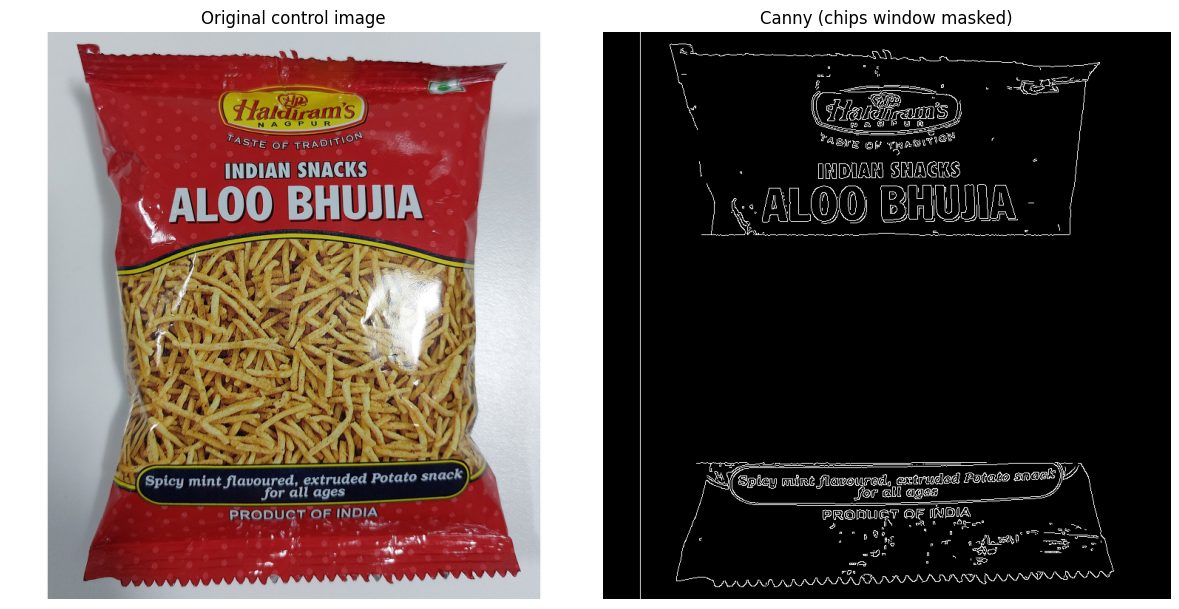


New edge map — chips region masked before Canny.
Mask region (fractional): (0.1, 0.36, 0.92, 0.76)
If the silhouette looks clean now, proceed to Cell 3.


In [6]:
def make_canny(image_path: str, low: int, high: int, target_size: int,
               mask_region=None) -> tuple[Image.Image, Image.Image]:
    """
    Load image, square-crop to target_size, optionally mask a region, run Canny,
    return (canny_map_as_PIL, original_cropped_as_PIL).

    mask_region: (x0_frac, y0_frac, x1_frac, y1_frac) in [0,1] coordinates of
    the target_size square. The region is filled with the median border colour
    BEFORE Canny runs, so the masked area produces no edges.
    """
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(image_path)
    # Resize + centre-crop to square (same as v1)
    h, w = img.shape[:2]
    scale = target_size / min(h, w)
    img = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_LANCZOS4)
    h, w = img.shape[:2]
    y0 = (h - target_size) // 2
    x0 = (w - target_size) // 2
    img = img[y0:y0 + target_size, x0:x0 + target_size]

    if mask_region is not None:
        x0f, y0f, x1f, y1f = mask_region
        mx0 = int(target_size * x0f); my0 = int(target_size * y0f)
        mx1 = int(target_size * x1f); my1 = int(target_size * y1f)
        # Sample border colour for a clean fill (not pure black; matches the surrounding pack)
        border = img[my0:my1, max(0, mx0-5):mx0]
        if border.size == 0:
            border = img[my0:my0+1, mx0:mx0+1]
        fill = tuple(int(c) for c in np.median(border.reshape(-1, 3), axis=0))
        img_masked = img.copy()
        cv2.rectangle(img_masked, (mx0, my0), (mx1, my1), fill, thickness=-1)
    else:
        img_masked = img

    gray = cv2.cvtColor(img_masked, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, low, high)
    edges_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
    return Image.fromarray(edges_rgb), Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))


# Mask out the chips window — bhujia occupies roughly y∈[0.32, 0.78], full width inside the pouch.
# Crop conservatively so we don't eat the "ALOO BHUJIA" title or the bottom callout pill.
CHIPS_MASK = (0.10, 0.36, 0.92, 0.76)   # (x0, y0, x1, y1) in image fraction

canny_map, control_rgb = make_canny(
    CONTROL_IMAGE, CANNY_LOW, CANNY_HIGH, RESOLUTION,
    mask_region=CHIPS_MASK,
)

# Save for reproducibility / dissertation figure
canny_path = OUT_DIR / "_canny_control.png"
canny_map.save(canny_path)
# Also save the masked source image so the methodology section can show the pipeline
masked_path = OUT_DIR / "_canny_control_source_masked.png"
Image.fromarray(cv2.cvtColor(
    cv2.rectangle(
        cv2.imread(CONTROL_IMAGE),
        (0, 0), (1, 1), (0, 0, 0), 1  # no-op marker
    ),
    cv2.COLOR_BGR2RGB
))  # we'll just keep the canny output for now

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(control_rgb); axes[0].set_title("Original control image"); axes[0].axis("off")
axes[1].imshow(canny_map); axes[1].set_title(f"Canny (chips window masked)"); axes[1].axis("off")
plt.tight_layout(); plt.show()

print()
print("New edge map — chips region masked before Canny.")
print(f"Mask region (fractional): {CHIPS_MASK}")
print("If the silhouette looks clean now, proceed to Cell 3.")

## Cell 3 — Load the full pipeline

Loads SDXL + ControlNet + IP-Adapter Plus + LoRA. This is the heaviest pipeline of the project — four conditioning components on a 6 GB card. Total load ~2–3 minutes.

In [7]:
print("Loading ViT-H image encoder (for IP-Adapter Plus)...")
t0 = time.time()
image_encoder = CLIPVisionModelWithProjection.from_pretrained(
    "h94/IP-Adapter",
    subfolder="models/image_encoder",
    torch_dtype=torch.float16,
)
print(f"  {time.time()-t0:.1f}s")

print("\nLoading Canny ControlNet for SDXL...")
t0 = time.time()
controlnet = ControlNetModel.from_pretrained(
    CONTROLNET_ID,
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True,
)
print(f"  {time.time()-t0:.1f}s")

print("\nLoading SDXL + ControlNet pipeline...")
t0 = time.time()
pipe = StableDiffusionXLControlNetPipeline.from_pretrained(
    MODEL_ID,
    controlnet=controlnet,
    image_encoder=image_encoder,
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True,
)
pipe.enable_model_cpu_offload()
pipe.enable_vae_slicing()
pipe.enable_vae_tiling()
print(f"  SDXL+ControlNet loaded in {time.time()-t0:.1f}s")

print("\nLoading IP-Adapter Plus...")
t0 = time.time()
pipe.load_ip_adapter(
    "h94/IP-Adapter",
    subfolder="sdxl_models",
    weight_name="ip-adapter-plus_sdxl_vit-h.safetensors",
)
if hasattr(pipe, "image_encoder") and pipe.image_encoder is not None:
    pipe.image_encoder.to("cuda")
print(f"  {time.time()-t0:.1f}s")

print("\nLoading LoRA...")
t0 = time.time()
pipe.load_lora_weights(str(LORA_PATH))
print(f"  {time.time()-t0:.1f}s")

print("\nPipeline fully loaded:  SDXL + ControlNet + IP-Adapter Plus + LoRA")

Loading ViT-H image encoder (for IP-Adapter Plus)...


Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

  2.9s

Loading Canny ControlNet for SDXL...


C:\Users\Vivek\Documents\dissertation\sdxl-env\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

C:\Users\Vivek\Documents\dissertation\sdxl-env\Lib\site-packages\diffusers\pipelines\pipeline_utils.py:2267: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionXLControlNetPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(
C:\Users\Vivek\Documents\dissertation\sdxl-env\Lib\site-packages\diffusers\pipelines\pipeline_utils.py:2294: FutureWarning: `enable_vae_tiling` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_tiling()` on a `StableDiffusionXLControlNetPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_tiling()`.
  deprecate(


  SDXL+ControlNet loaded in 3.2s

Loading IP-Adapter Plus...
  2.4s

Loading LoRA...


No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  1.8s

Pipeline fully loaded:  SDXL + ControlNet + IP-Adapter Plus + LoRA


## Cell 4 — Memory test (one image) before the long run

Generate one image to confirm everything fits in 6 GB VRAM. If this OOMs, the cell will catch it and tell us to drop to 640. Don't proceed to Cell 5 until this works.

  0%|          | 0/25 [00:00<?, ?it/s]

C:\Users\Vivek\Documents\dissertation\sdxl-env\Lib\site-packages\diffusers\pipelines\controlnet\pipeline_controlnet_sd_xl.py:928: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


Smoke test at 768x768: 1736.8s


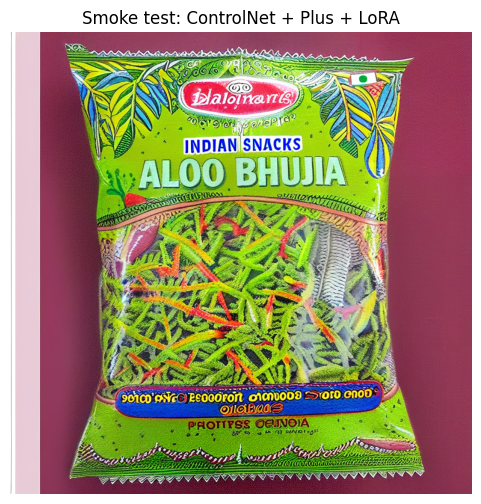


Look at this image. You should see:
  - The Haldiram's pouch silhouette (top crimp, bottom zig-zag) — that's ControlNet working
  - Madhubani decoration on top — that's IP-Adapter Plus
  - Snack-pack styling (foil, brand zones) — that's LoRA
If all three are visible, the pipeline works. Proceed to Cell 5.


In [8]:
def try_generate_at(res):
    global canny_map, control_rgb
    canny_map_at, _ = make_canny(CONTROL_IMAGE, CANNY_LOW, CANNY_HIGH, res)
    pipe.set_ip_adapter_scale(IP_SCALE)
    ref = load_image(REFERENCES["madhubani"])
    g = torch.Generator(device="cuda").manual_seed(42)
    t0 = time.time()
    img = pipe(
        prompt=PROMPT_LORA,
        negative_prompt=NEGATIVE,
        image=canny_map_at,
        ip_adapter_image=ref,
        controlnet_conditioning_scale=0.7,
        width=res, height=res,
        num_inference_steps=STEPS,
        guidance_scale=GUIDANCE,
        generator=g,
        cross_attention_kwargs={"scale": LORA_SCALE},
    ).images[0]
    return img, time.time() - t0

try:
    img, elapsed = try_generate_at(RESOLUTION)
    print(f"Smoke test at {RESOLUTION}x{RESOLUTION}: {elapsed:.1f}s")
except torch.cuda.OutOfMemoryError:
    print(f"OOM at {RESOLUTION}. Falling back to 640.")
    gc.collect(); torch.cuda.empty_cache()
    RESOLUTION = 640
    img, elapsed = try_generate_at(RESOLUTION)
    print(f"Smoke test at 640x640: {elapsed:.1f}s")

img.save(OUT_DIR / "_smoke_test.png")
plt.figure(figsize=(6, 6))
plt.imshow(img); plt.axis("off"); plt.title("Smoke test: ControlNet + Plus + LoRA")
plt.show()

print()
print("Look at this image. You should see:")
print("  - The Haldiram's pouch silhouette (top crimp, bottom zig-zag) — that's ControlNet working")
print("  - Madhubani decoration on top — that's IP-Adapter Plus")
print("  - Snack-pack styling (foil, brand zones) — that's LoRA")
print("If all three are visible, the pipeline works. Proceed to Cell 5.")

  0%|          | 0/25 [00:01<?, ?it/s]

cn=0.3: 1331.2s


  0%|          | 0/25 [00:00<?, ?it/s]

cn=0.5: 1032.8s


  0%|          | 0/25 [00:02<?, ?it/s]

cn=0.7: 1171.4s


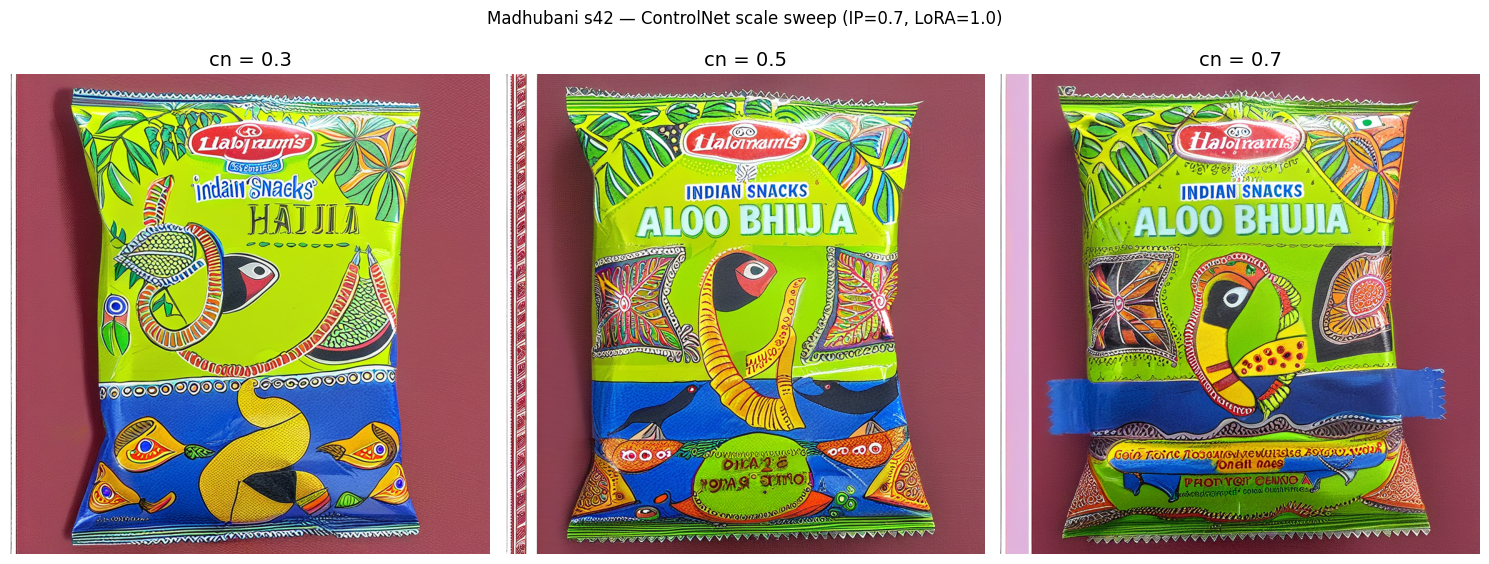


Strip saved: ..\outputs\spike\v4_controlnet\_mini_scale_sweep_strip.png


In [9]:
# Mini-spike: scale sweep on Madhubani only, seed=42 fixed
import time
from PIL import ImageDraw, ImageFont
import matplotlib.pyplot as plt

mini_scales = [0.3, 0.5, 0.7]
mini_out_dir = OUT_DIR / "_mini_scale_sweep"
mini_out_dir.mkdir(parents=True, exist_ok=True)

mini_ref = load_image(REFERENCES["madhubani"])
pipe.set_ip_adapter_scale(IP_SCALE)

results = []
for cn in mini_scales:
    out_path = mini_out_dir / f"madhubani_s42_cn{int(cn*10):02d}.png"
    if out_path.exists():
        img = Image.open(out_path)
        print(f"SKIP cn={cn}")
    else:
        g = torch.Generator(device="cuda").manual_seed(42)
        t0 = time.time()
        img = pipe(
            prompt=PROMPT_LORA, negative_prompt=NEGATIVE,
            image=canny_map, ip_adapter_image=mini_ref,
            controlnet_conditioning_scale=cn,
            width=RESOLUTION, height=RESOLUTION,
            num_inference_steps=STEPS, guidance_scale=GUIDANCE,
            generator=g, cross_attention_kwargs={"scale": LORA_SCALE},
        ).images[0]
        img.save(out_path)
        print(f"cn={cn}: {time.time()-t0:.1f}s")
    results.append((cn, img))

# Build a tidy comparison strip with the smoke test (cn=0.7) for context
fig, axes = plt.subplots(1, len(results), figsize=(15, 6))
for ax, (cn, img) in zip(axes, results):
    ax.imshow(img); ax.axis("off"); ax.set_title(f"cn = {cn}", fontsize=14)
plt.suptitle("Madhubani s42 — ControlNet scale sweep (IP=0.7, LoRA=1.0)", fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / "_mini_scale_sweep_strip.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"\nStrip saved: {OUT_DIR / '_mini_scale_sweep_strip.png'}")

## Cell 5 — Full spike grid (12 images)

Resume-safe; existing outputs are skipped.

In [11]:
canny_map, _ = make_canny(CONTROL_IMAGE, CANNY_LOW, CANNY_HIGH, RESOLUTION)

def generate(prompt, ref_path, seed, cn_scale, out_path):
    if out_path.exists():
        return None
    pipe.set_ip_adapter_scale(IP_SCALE)
    ref = load_image(ref_path)
    g = torch.Generator(device="cuda").manual_seed(seed)
    t0 = time.time()
    img = pipe(
        prompt=prompt,
        negative_prompt=NEGATIVE,
        image=canny_map,
        ip_adapter_image=ref,
        controlnet_conditioning_scale=cn_scale,
        width=RESOLUTION, height=RESOLUTION,
        num_inference_steps=STEPS,
        guidance_scale=GUIDANCE,
        generator=g,
        cross_attention_kwargs={"scale": LORA_SCALE},
    ).images[0]
    elapsed = time.time() - t0
    img.save(out_path, "PNG")
    cfg = {
        "prompt": prompt, "negative_prompt": NEGATIVE,
        "seed": seed,
        "controlnet_scale": cn_scale,
        "ip_adapter_scale": IP_SCALE,
        "lora_scale": LORA_SCALE,
        "lora_path": str(LORA_PATH),
        "control_image": CONTROL_IMAGE,
        "canny_low": CANNY_LOW, "canny_high": CANNY_HIGH,
        "reference": str(ref_path),
        "width": RESOLUTION, "height": RESOLUTION,
        "steps": STEPS, "guidance": GUIDANCE,
        "model": MODEL_ID, "controlnet": CONTROLNET_ID,
        "elapsed_s": round(elapsed, 1),
    }
    out_path.with_suffix(".json").write_text(json.dumps(cfg, indent=2))
    return elapsed

tasks = []
for tradition, ref_path in REFERENCES.items():
    for seed in SEEDS:
        for cn_scale in CONTROLNET_SCALES:
            cn_tag = f"{cn_scale:.1f}".replace(".", "")
            out = OUT_DIR / f"cn{cn_tag}_{tradition}_s{seed}.png"
            tasks.append({"prompt": PROMPT_LORA, "ref": ref_path,
                          "seed": seed, "cn_scale": cn_scale, "out": out,
                          "tag": f"cn={cn_scale} {tradition} s{seed}"})

print(f"Total: {len(tasks)} tasks")
grand = time.time()
for i, t in enumerate(tasks, 1):
    if t["out"].exists():
        print(f"[{i:>2}/{len(tasks)}] SKIP {t['tag']}")
        continue
    print(f"[{i:>2}/{len(tasks)}] {t['tag']} ...", end=" ", flush=True)
    e = generate(t["prompt"], t["ref"], t["seed"], t["cn_scale"], t["out"])
    print("SKIP" if e is None else f"{e:.1f}s")

print(f"\nTotal runtime: {(time.time()-grand)/60:.1f} min")
print(f"Outputs: {OUT_DIR.resolve()}")

Total: 12 tasks
[ 1/12] cn=0.4 madhubani s42 ... 

  0%|          | 0/25 [00:00<?, ?it/s]

962.3s
[ 2/12] cn=0.5 madhubani s42 ... 

  0%|          | 0/25 [00:01<?, ?it/s]

940.1s
[ 3/12] cn=0.4 madhubani s1337 ... 

...

931.3s
[11/12] cn=0.4 kalighat s1337 ... 

  0%|          | 0/25 [00:01<?, ?it/s]

1250.5s
[12/12] cn=0.5 kalighat s1337 ... 

  0%|          | 0/25 [00:01<?, ?it/s]

992.9s

Total runtime: 207.2 min
Outputs: C:\Users\Vivek\Documents\dissertation\outputs\spike\v4_controlnet


## Cell 6 — Three-way comparison grid: v3 (no ControlNet) vs v4 cn=0.5 vs v4 cn=0.8

Rows = tradition × seed (6 rows). Three columns showing the progression as we add ControlNet. Tells the story at a glance.

In [16]:
print("Files in v4_controlnet directory:")
for p in sorted(OUT_DIR.glob("cn*.png")):
    print(f"  {p.name}")

Files in v4_controlnet directory:
  cn04_kalighat_s1337.png
  cn04_kalighat_s42.png
  cn04_madhubani_s1337.png
  cn04_madhubani_s42.png
  cn04_tanjore_s1337.png
  cn04_tanjore_s42.png
  cn05_kalighat_s1337.png
  cn05_kalighat_s42.png
  cn05_madhubani_s1337.png
  cn05_madhubani_s42.png
  cn05_tanjore_s1337.png
  cn05_tanjore_s42.png


Three-way comparison: C:\Users\Vivek\Documents\dissertation\outputs\spike\v4_three_way_comparison.png


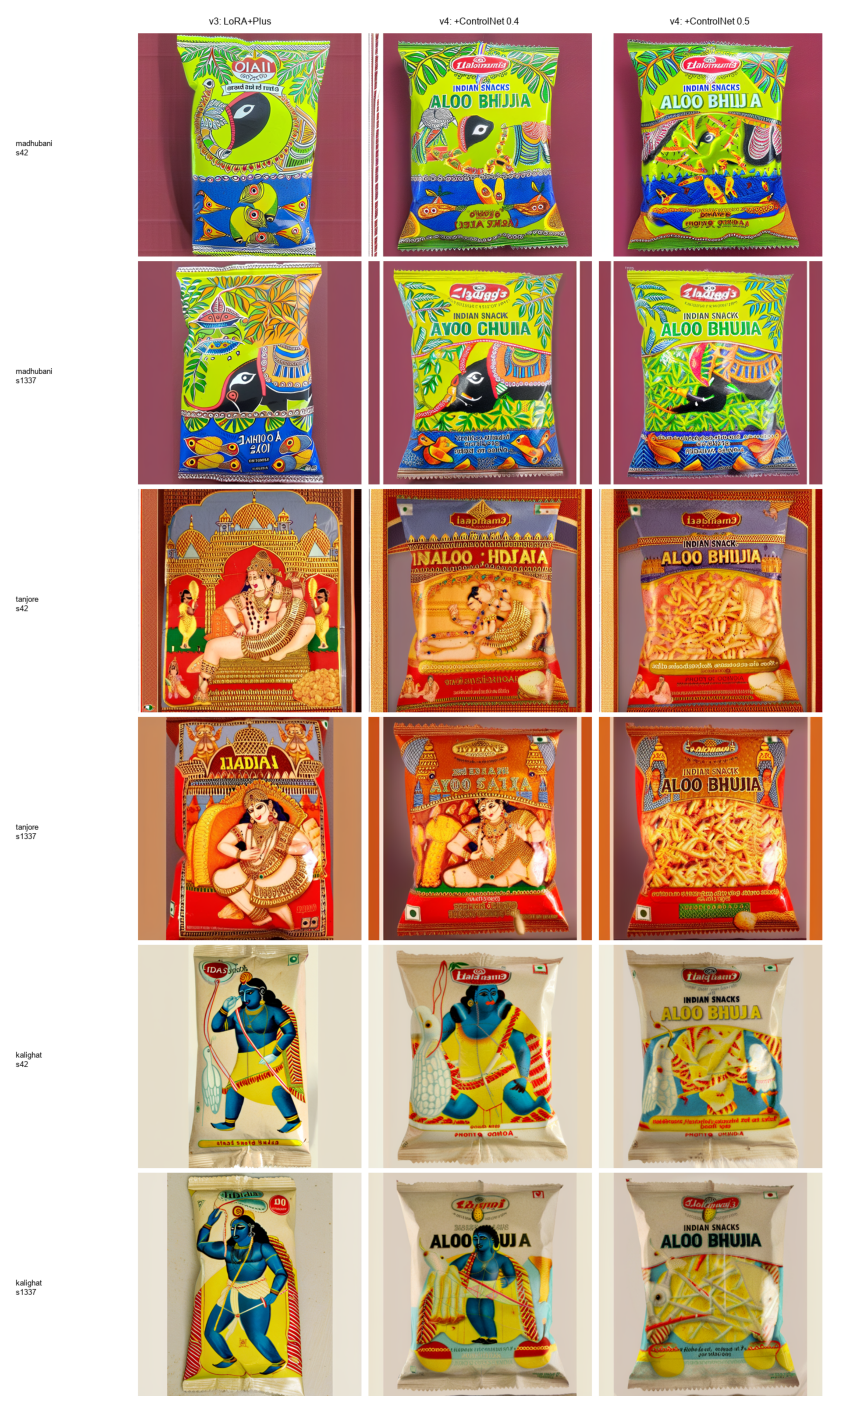


Diagnostic — file presence per cell:
  madhubani s42: v3=OK, cn04=OK, cn05=OK
  madhubani s1337: v3=OK, cn04=OK, cn05=OK
  tanjore s42: v3=OK, cn04=OK, cn05=OK
  tanjore s1337: v3=OK, cn04=OK, cn05=OK
  kalighat s42: v3=OK, cn04=OK, cn05=OK
  kalighat s1337: v3=OK, cn04=OK, cn05=OK


In [17]:
V3_DIR = Path("../outputs/spike/v3_lora_plus")
thumb = 384
label_w = 220
col_gap = 12
header_h = 40

rows = []
for tradition in REFERENCES.keys():
    for seed in SEEDS:
        v3 = V3_DIR / f"lora_plus_{tradition}_s{seed}.png"
        v4_04 = OUT_DIR / f"cn04_{tradition}_s{seed}.png"
        v4_05 = OUT_DIR / f"cn05_{tradition}_s{seed}.png"
        rows.append({
            "label": f"{tradition}\ns{seed}",
            "v3": Image.open(v3).resize((thumb, thumb)) if v3.exists() else None,
            "v4_04": Image.open(v4_04).resize((thumb, thumb)) if v4_04.exists() else None,
            "v4_05": Image.open(v4_05).resize((thumb, thumb)) if v4_05.exists() else None,
        })

n_rows = len(rows)
canvas_w = label_w + 3 * thumb + 2 * col_gap + 20
canvas_h = header_h + n_rows * thumb + (n_rows - 1) * 8
canvas = Image.new("RGB", (canvas_w, canvas_h), "white")
draw = ImageDraw.Draw(canvas)
try:
    font = ImageFont.truetype("arial.ttf", 16)
    font_small = ImageFont.truetype("arial.ttf", 13)
except Exception:
    font = font_small = ImageFont.load_default()

col_x = [label_w, label_w + thumb + col_gap, label_w + 2 * thumb + 2 * col_gap]
for x, title in zip(col_x, ["v3: LoRA+Plus", "v4: +ControlNet 0.4", "v4: +ControlNet 0.5"]):
    draw.text((x + thumb // 2 - 70, 10), title, fill="black", font=font)

y = header_h
for r in rows:
    draw.text((10, y + thumb // 2 - 10), r["label"], fill="black", font=font_small)
    for img, x in zip([r["v3"], r["v4_04"], r["v4_05"]], col_x):
        if img is not None:
            canvas.paste(img, (x, y))
    y += thumb + 8

grid_path = OUT_DIR.parent / "v4_three_way_comparison.png"
canvas.save(grid_path)
print(f"Three-way comparison: {grid_path.resolve()}")
plt.figure(figsize=(14, 18)); plt.imshow(canvas); plt.axis("off"); plt.show()

# Diagnostic — confirms what was found and what wasn't
print("\nDiagnostic — file presence per cell:")
for r in rows:
    print(f"  {r['label'].replace(chr(10), ' ')}: "
          f"v3={'OK' if r['v3'] is not None else 'MISSING'}, "
          f"cn04={'OK' if r['v4_04'] is not None else 'MISSING'}, "
          f"cn05={'OK' if r['v4_05'] is not None else 'MISSING'}")

## Cell 7 — Failure-log CSV scaffold (rubric scoring)

In [15]:
import pandas as pd
rows = []
for p in sorted(OUT_DIR.glob("cn*.png")):
    stem = p.stem
    parts = stem.split("_")
    cn_str = parts[0].replace("cn", "")
    cn_scale = f"{cn_str[0]}.{cn_str[1:]}" if len(cn_str) > 1 else cn_str
    tradition = parts[1]
    seed = parts[-1].lstrip("s")
    rows.append({
        "filename": p.name, "tradition": tradition, "cn_scale": cn_scale, "seed": seed,
        "session1_text_legibility": "",
        "session1_regional_appropriateness": "",
        "session1_packaging_plausibility": "",
        "session1_visual_quality": "",
        "session1_date": "",
        "session2_text_legibility": "",
        "session2_regional_appropriateness": "",
        "session2_packaging_plausibility": "",
        "session2_visual_quality": "",
        "session2_date": "",
        "failure_mode": "", "notes": "",
    })
df = pd.DataFrame(rows)
log_path = Path("../evaluation/spike_v4_scores.csv")
log_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(log_path, index=False)
print(f"Score scaffold: {log_path.resolve()}  ({len(df)} rows)")

Score scaffold: C:\Users\Vivek\Documents\dissertation\evaluation\spike_v4_scores.csv  (12 rows)


## Cell 8 — Configuration

In [18]:
# === LoRA-scale ablation: fixed CN=0.4, IP=0.7, vary LoRA across 3 traditions × 2 seeds ===
# Total: 18 images. Expected runtime ~2 to 2.5 hours.

ABLATION_OUT_DIR = Path("../outputs/spike/v5_lora_ablation")
ABLATION_OUT_DIR.mkdir(parents=True, exist_ok=True)

LORA_SCALES = [0.5, 0.7, 1.0]
FIXED_CN_SCALE = 0.4      # chosen operating point from spike v4
# IP_SCALE already 0.7 from spike v4 config (carries through)

print(f"Output dir:        {ABLATION_OUT_DIR.resolve()}")
print(f"Fixed:             IP_scale={IP_SCALE}, ControlNet_scale={FIXED_CN_SCALE}")
print(f"Variable:          LoRA_scale in {LORA_SCALES}")
print(f"Traditions × seeds: {len(REFERENCES)} × {len(SEEDS)}")
print(f"Total tasks:       {len(REFERENCES) * len(SEEDS) * len(LORA_SCALES)} images")

Output dir:        C:\Users\Vivek\Documents\dissertation\outputs\spike\v5_lora_ablation
Fixed:             IP_scale=0.7, ControlNet_scale=0.4
Variable:          LoRA_scale in [0.5, 0.7, 1.0]
Traditions × seeds: 3 × 2
Total tasks:       18 images


## Cell 9 — Generation loop (the long one)

In [19]:
def ablation_generate(prompt, ref_path, seed, lora_scale, out_path):
    if out_path.exists():
        return None
    pipe.set_ip_adapter_scale(IP_SCALE)
    ref = load_image(ref_path)
    g = torch.Generator(device="cuda").manual_seed(seed)
    t0 = time.time()
    img = pipe(
        prompt=prompt,
        negative_prompt=NEGATIVE,
        image=canny_map,
        ip_adapter_image=ref,
        controlnet_conditioning_scale=FIXED_CN_SCALE,
        width=RESOLUTION, height=RESOLUTION,
        num_inference_steps=STEPS,
        guidance_scale=GUIDANCE,
        generator=g,
        cross_attention_kwargs={"scale": lora_scale},
    ).images[0]
    elapsed = time.time() - t0
    img.save(out_path, "PNG")
    cfg = {
        "prompt": prompt, "negative_prompt": NEGATIVE,
        "seed": seed,
        "lora_scale": lora_scale,
        "controlnet_scale": FIXED_CN_SCALE,
        "ip_adapter_scale": IP_SCALE,
        "lora_path": str(LORA_PATH),
        "control_image": CONTROL_IMAGE,
        "reference": str(ref_path),
        "width": RESOLUTION, "height": RESOLUTION,
        "steps": STEPS, "guidance": GUIDANCE,
        "model": MODEL_ID, "controlnet": CONTROLNET_ID,
        "elapsed_s": round(elapsed, 1),
    }
    out_path.with_suffix(".json").write_text(json.dumps(cfg, indent=2))
    return elapsed


# Build task list
tasks = []
for tradition, ref_path in REFERENCES.items():
    for seed in SEEDS:
        for lora_scale in LORA_SCALES:
            lora_tag = f"{int(lora_scale * 10):02d}"
            out = ABLATION_OUT_DIR / f"lora{lora_tag}_{tradition}_s{seed}.png"
            tasks.append({
                "prompt": PROMPT_LORA, "ref": ref_path,
                "seed": seed, "lora_scale": lora_scale, "out": out,
                "tag": f"lora={lora_scale} {tradition} s{seed}",
            })

print(f"Total tasks: {len(tasks)}")
already = sum(1 for t in tasks if t["out"].exists())
print(f"Already done (resume-safe skip): {already}")
print(f"To do: {len(tasks) - already}")
print()

grand = time.time()
for i, t in enumerate(tasks, 1):
    if t["out"].exists():
        print(f"[{i:>2}/{len(tasks)}] SKIP {t['tag']}")
        continue
    print(f"[{i:>2}/{len(tasks)}] {t['tag']} ...", end=" ", flush=True)
    e = ablation_generate(t["prompt"], t["ref"], t["seed"], t["lora_scale"], t["out"])
    print("SKIP" if e is None else f"{e:.1f}s")

print(f"\nTotal runtime: {(time.time()-grand)/60:.1f} min")
print(f"Outputs: {ABLATION_OUT_DIR.resolve()}")

Total tasks: 18
Already done (resume-safe skip): 0
To do: 18

[ 1/18] lora=0.5 madhubani s42 ... 

  0%|          | 0/25 [00:00<?, ?it/s]

C:\Users\Vivek\Documents\dissertation\sdxl-env\Lib\site-packages\diffusers\pipelines\controlnet\pipeline_controlnet_sd_xl.py:928: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


1107.2s
[ 2/18] lora=0.7 madhubani s42 ... 

  0%|          | 0/25 [00:02<?, ?it/s]

...

1350.8s
[17/18] lora=0.7 kalighat s1337 ... 

  0%|          | 0/25 [00:06<?, ?it/s]

860.4s
[18/18] lora=1.0 kalighat s1337 ... 

  0%|          | 0/25 [00:02<?, ?it/s]

956.3s

Total runtime: 290.5 min
Outputs: C:\Users\Vivek\Documents\dissertation\outputs\spike\v5_lora_ablation


## Cell 10 — Three-way comparison grid (LoRA=0.5 vs 0.7 vs 1.0)

Ablation grid saved: C:\Users\Vivek\Documents\dissertation\outputs\spike\v5_lora_ablation_grid.png


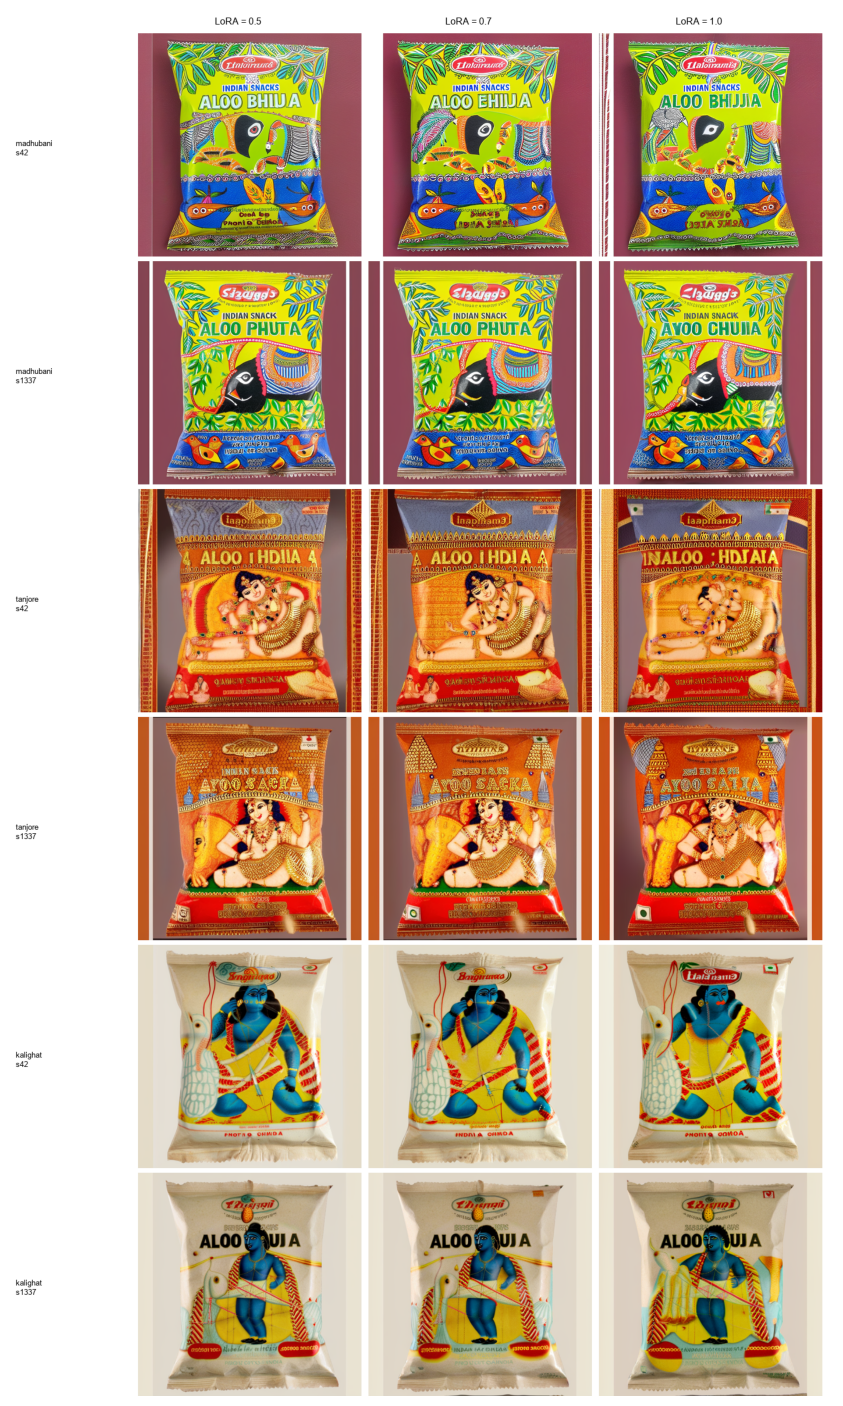

Score scaffold: C:\Users\Vivek\Documents\dissertation\evaluation\spike_v5_lora_scores.csv  (18 rows)


In [20]:
from PIL import ImageDraw, ImageFont
import matplotlib.pyplot as plt

thumb = 384
label_w = 220
col_gap = 12
header_h = 40

rows = []
for tradition in REFERENCES.keys():
    for seed in SEEDS:
        cells = {}
        for lora_scale in LORA_SCALES:
            lora_tag = f"{int(lora_scale * 10):02d}"
            p = ABLATION_OUT_DIR / f"lora{lora_tag}_{tradition}_s{seed}.png"
            cells[lora_scale] = Image.open(p).resize((thumb, thumb)) if p.exists() else None
        rows.append({"label": f"{tradition}\ns{seed}", "cells": cells})

n_rows = len(rows)
canvas_w = label_w + len(LORA_SCALES) * thumb + (len(LORA_SCALES) - 1) * col_gap + 20
canvas_h = header_h + n_rows * thumb + (n_rows - 1) * 8
canvas = Image.new("RGB", (canvas_w, canvas_h), "white")
draw = ImageDraw.Draw(canvas)
try:
    font = ImageFont.truetype("arial.ttf", 16)
    font_small = ImageFont.truetype("arial.ttf", 13)
except Exception:
    font = font_small = ImageFont.load_default()

col_x = [label_w + i * (thumb + col_gap) for i in range(len(LORA_SCALES))]
for x, lora_scale in zip(col_x, LORA_SCALES):
    draw.text((x + thumb // 2 - 60, 10), f"LoRA = {lora_scale}", fill="black", font=font)

y = header_h
for r in rows:
    draw.text((10, y + thumb // 2 - 10), r["label"], fill="black", font=font_small)
    for lora_scale, x in zip(LORA_SCALES, col_x):
        img = r["cells"][lora_scale]
        if img is not None:
            canvas.paste(img, (x, y))
    y += thumb + 8

grid_path = ABLATION_OUT_DIR.parent / "v5_lora_ablation_grid.png"
canvas.save(grid_path)
print(f"Ablation grid saved: {grid_path.resolve()}")
plt.figure(figsize=(16, 18))
plt.imshow(canvas); plt.axis("off"); plt.show()

# Score scaffold for the rubric
import pandas as pd
rows_for_csv = []
for p in sorted(ABLATION_OUT_DIR.glob("lora*.png")):
    parts = p.stem.split("_")
    lora_raw = parts[0].replace("lora", "")
    lora_scale = f"{lora_raw[0]}.{lora_raw[1:]}" if len(lora_raw) > 1 else lora_raw
    tradition = parts[1]
    seed = parts[-1].lstrip("s")
    rows_for_csv.append({
        "filename": p.name, "tradition": tradition,
        "lora_scale": lora_scale, "seed": seed,
        "session1_text_legibility": "",
        "session1_regional_appropriateness": "",
        "session1_packaging_plausibility": "",
        "session1_visual_quality": "",
        "session1_date": "",
        "session2_text_legibility": "",
        "session2_regional_appropriateness": "",
        "session2_packaging_plausibility": "",
        "session2_visual_quality": "",
        "session2_date": "",
        "failure_mode": "", "notes": "",
    })
df = pd.DataFrame(rows_for_csv)
log_path = Path("../evaluation/spike_v5_lora_scores.csv")
log_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(log_path, index=False)
print(f"Score scaffold: {log_path.resolve()}  ({len(df)} rows)")